# Two-Layer Grid

In [2]:
using DifferentialEquations
using LightGraphs
using GraphRecipes
using Statistics
using LaTeXStrings
using Plots
using LinearAlgebra
using Plotly

HTML{String}("<script>\n// Immediately-invoked-function-expression to avoid global variables.\n(function() {\n    var warning_div = document.getElementById(\"webio-warning-15144747408205592413\");\n    var hide = function () {\n        var script = document.getElementById(\"webio-setup-14427565061942654540\");\n        var parent = script && script.parentElement;\n        var grandparent = parent && parent.parentElement;\n        if (grandparent) {\n            grandparent.style.display = \"none\";\n        }\n        warning_div.style.display = \"none\";\n    };\n    if (typeof Jupyter !== \"undefined\") {\n        console.log(\"WebIO detected Jupyter notebook environment.\");\n        // Jupyter notebook.\n        var extensions = (\n            Jupyter\n            && Jupyter.notebook.config.data\n            && Jupyter.notebook.config.data.load_extensions\n        );\n        if (extensions && extensions[\"webio-jupyter-notebook\"]) {\n            // Extension already loaded.\n            console.log(\"Jupyter WebIO nbextension detected; not loading ad-hoc.\");\n            hide();\n            return;\n        }\n    } else if (window.location.pathname.includes(\"/lab\")) {\n        // Guessing JupyterLa\n        console.log(\"Jupyter Lab detected; make sure the @webio/jupyter-lab-provider labextension is installed.\");\n        hide();\n        return;\n    }\n})();\n\n</script>\n<p\n    id=\"webio-warning-15144747408205592413\"\n    class=\"output_text output_stderr\"\n    style=\"padding: 1em; font-weight: bold;\"\n>\n    Unable to load WebIO. Please make sure WebIO works for your Jupyter client.\n    For troubleshooting, please see <a href=\"https://juliagizmos.github.io/WebIO.jl/latest/providers/ijulia/\">\n    the WebIO/IJulia documentation</a>.\n    <!-- TODO: link to installation docs. -->\n</p>\n")

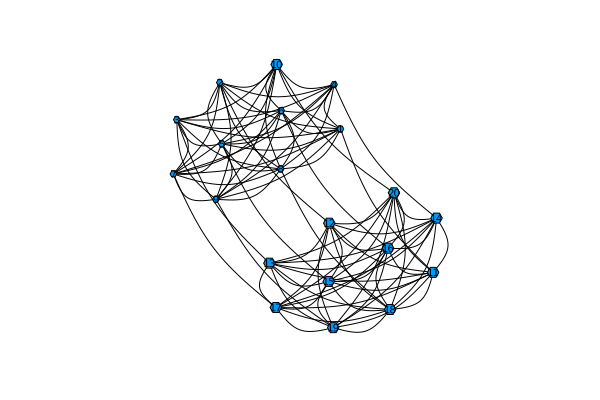

In [3]:
g1=CompleteGraph(20)
int=Int(nv(g1)/2)
for i in 1:int
    for j in (int+1):Int(2*int)
        rem_edge!(g1,i,j)
    end
    add_edge!(g1,i,int+i)
end
graphplot(g1,names=1:20)

In [4]:
function G_generate(C)
    U, Σ, V = svd(C)
    U*diagm(0 => sqrt.(Σ))*U'
end

G_generate (generic function with 1 method)

In [5]:
function r2N(grid,sol,tspan)
    N=Int(nv(grid))
    Δt=tspan[2]-tspan[1]
    leng=length(sol[1,1:end])
    A=[exp.(sol[i,1:end].*im) for i in 1:N]
    B=zeros(leng)
    for i in 1:N
        B=B.+A[i]
    end
    return (1/Δt)*sum(abs2.((1/N)*B)*Δt/(leng-1))
end

r2N (generic function with 1 method)

# Kuramoto Model

$$C= \begin{bmatrix}
1 & \rho & \rho & \rho\\
\rho & 1 & \rho & \rho\\
\rho & \rho & 1 & \rho\\
\rho & \rho & \rho & 1
\end{bmatrix}$$

In [9]:
function gmatrix(n,ρ,σ)
int=Int(n/2)
C=ρ*ones(n,n)
C[diagind(C)] .= 1
for i in 1:int
C[(int+1):end,i]=ρ*ones(int)
end
for i in (int+1):n
    C[1:int,i]=ρ*ones(int)
end
G=(σ/sqrt(2))*G_generate(C)
return G
end

gmatrix (generic function with 1 method)

In [10]:
function soltnN(grid,w,k,u0,tspan,σ,ρ)
    E=incidence_matrix(grid;oriented=true)
    n=nv(grid)
    
    function f(du,u,p,t)
        for i in 1:n
            du[i]=w[i]+(k/n)*sum([sin(u[j]-u[i]) for j in 1:n])
        end
    end
    
    function g(du,u,p,t)
        du.=gmake(n,ρ,σ)
    end
    
    prob=SDEProblem(f,g,u0,tspan,noise_rate_prototype=zeros(n,n))
    sol=solve(prob,ImplicitEM(),dt=0.04)
    return sol
end

soltnN (generic function with 1 method)

In [13]:
#Kuramoto Plot
w=vcat(-(1/2)*ones(10),(1/2)*ones(10))
tf=3500.0
u0=rand(20)
e(k)=r2N(soltnN(g1,w,k,u0,(0.0,tf),sqrt(2),-1),(0.0,tf))
f(k)=r2N(soltnN(g1,w,k,u0,(0.0,tf),sqrt(2),-0.5),(0.0,tf))
g(k)=r2N(soltnN(g1,w,k,u0,(0.0,tf),sqrt(2),0),(0.0,tf))
h(k)=r2N(soltnN(g1,w,k,u0,(0.0,tf),sqrt(2),0.5),(0.0,tf))
i(k)=r2N(soltnN(g1,w,k,u0,(0.0,tf),sqrt(2),1),(0.0,tf))
ks=LinRange(0,3,150)
edat1=e.(ks)
fdat1=f.(ks)
gdat1=g.(ks)
hdat1=h.(ks)
idat1=i.(ks)
Plots.plot(ks,[edat1,fdat1,gdat1,hdat1,idat1],title= L"\overline{R^2} \textrm{ vs. k for Several ρ}",label=["-1.0" "-0.5" "0" "0.5" "1.0"],xlabel="k",ylabel=L"\overline{R^2}",width=3)

LoadError: InterruptException:

In [34]:
#KM Heatmap with rho covariance (K on y-axis, rho on x-axis)
w=vcat(-(1/2)*ones(10),(1/2)*ones(10))
u0=zeros(nv(g1))
tf=1000.0
size=100
xs3 = [string(i/size) for i = -size:size]
ys3 = [string(2*i/size) for i = 1:size]
z3 = float((1:size) * reshape(1:(2*size+1), 1, :))
for b in 1:size
    for j in 1:(2*size+1)
        z3[b,j]=r2N(g1,soltnN(g1,w,2*b/size,u0,(0,tf),sqrt(2),(j-size-1)/size),(0.0,tf))
    end
end

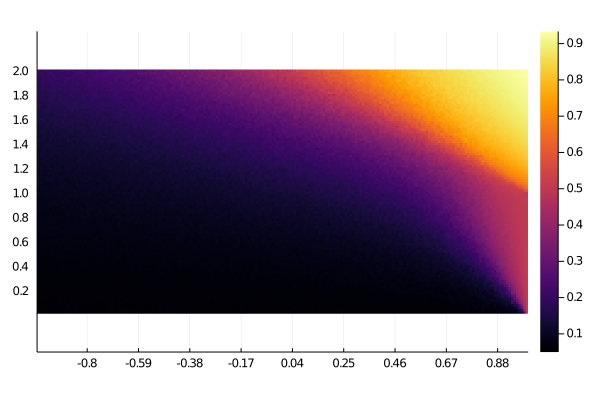

In [35]:
Plots.heatmap(xs3,ys3,z3,aspect_ratio=1)

In [37]:
#KM Heatmap Save
using Plotly
Plotly.signin("trs3","n3lr1fNnHZO2eMj4FUhv")
Plotly.set_credentials_file(Dict("username"=>"trs3","api_key"=>"n3lr1fNnHZO2eMj4FUhv"))
my_plot = Plotly.plot([Plotly.heatmap(x=xs3,y=ys3,z=z3')])
post(my_plot)


RemotePlot(HTTP.URI("https://chart-studio.plotly.com/~trs3/39"))

# Swing Equation

In [29]:
function swingsoltnN(grid,D,B,P,M,u0,tspan,σ,ρ)
    E=incidence_matrix(grid;oriented=true)
    n=nv(grid)
    
    function f(du,u,p,t)
        du[1:n]=u[n+1:2n]
        du[n+1:2n] = (-D.*u[n+1:2n] - E*((B/n).*sin.(E'*u[1:n])) + P)./M 
    end
    
    function g(du,u,p,t)
        A=zeros(2n,2n)
        int=Int(n/2)
        C=ρ*ones(n,n)
        C[diagind(C)] .= 1
        for i in 1:int
            C[(int+1):end,i]=ρ*ones(int)
        end
        for i in (int+1):n
            C[1:int,i]=ρ*ones(int)
        end
        G=(σ/sqrt(2))*G_generate(C)
        for i in 1:n
            A[n+i,1:2n]=vcat(zeros(n),G[i,1:n])
        end
        du.=A
    end
    
    prob=SDEProblem(f,g,u0,tspan,noise_rate_prototype=zeros(2n,2n))
    sol=solve(prob,ImplicitEM(),dt=0.04)
    return sol
end

swingsoltnN (generic function with 1 method)

In [20]:
#Run Tonight
tf=2000.0
D=ones(nv(g1))
M=ones(nv(g1))
P=rand(nv(g1))
P=P.-mean(P)
u0=zeros(2*nv(g1))
a(b)=r2N(swingsoltnN(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),-1),(0.0,tf))
c(b)=r2N(swingsoltnN(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),-0.5),(0.0,tf))
d(b)=r2N(swingsoltnN(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),0),(0.0,tf))
e(b)=r2N(swingsoltnN(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),0.5),(0.0,tf))
f(b)=r2N(swingsoltnN(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),1.0),(0.0,tf))
ks=LinRange(0,3,150)
adat2=a.(ks)
cdat2=c.(ks)
ddat2=d.(ks)
edat2=e.(ks)
fdat2=f.(ks)
Plots.plot(ks,[adat2,cdat2,ddat2,edat2,fdat2],title= L"\overline{R^2} \textrm{ vs. B for Several ρ}",label=["-1.0" "-0.5" "0" "0.5" "1.0"],xlabel="B",ylabel=L"\overline{R^2}",width=3)


LoadError: InterruptException:

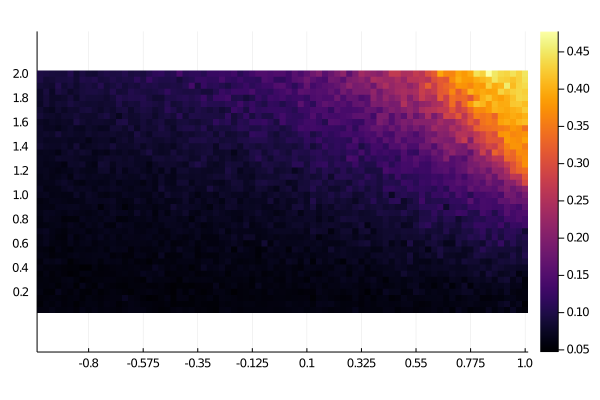

In [30]:
#Swing heatmap with rho covariance
using Plotly
tf=500.0
D=ones(nv(g1))
M=ones(nv(g1))
P=rand(nv(g1))
P=P.-mean(P)
u0=zeros(2*nv(g1))
size=40
xs4 = [string(i/size) for i = -size:size]
ys4 = [string(2*i/size) for i = 1:size]
z4 = float((1:size) * reshape(1:(2*size+1), 1, :))
for b in 1:size
    for j in 1:(2*size+1)
        z4[b,j]=r2N(g1,swingsoltnN(g1,D,(2*b/size)*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),(j-size-1)/size),(0.0,tf))
    end
end
Plots.heatmap(xs4,ys4,z4,aspect_ratio=1)

In [31]:
#Swing heatmap save
using Plotly
Plotly.signin("trs3","n3lr1fNnHZO2eMj4FUhv")
Plotly.set_credentials_file(Dict("username"=>"trs3","api_key"=>"n3lr1fNnHZO2eMj4FUhv"))
my_plot = Plotly.plot([Plotly.heatmap(x=xs4,y=ys4,z=z4')])
post(my_plot)

RemotePlot(HTTP.URI("https://chart-studio.plotly.com/~trs3/35"))